In [1]:
# 1. 고객, 주문 데이터 재작성

import pandas as pd

customers = pd.DataFrame({
    "customer_id": [1, 2, 3, 4],
    "customer": ["Kim", "Lee", "Park", "Choi"],
    "region": ["Seoul", "Busan", "Seoul", "Incheon"]
})

orders = pd.DataFrame({
    "order_id": [101, 102, 103, 104, 105, 106],
    "customer_id": [1, 2, 1, 3, 3, 1],
    "product": ["A", "B", "C", "A", "B", "B"],
    "sales": [120000, 85000, 95000, 250000, 180000, 160000]
})

- customers 한 행: 고객 1명
- orders 한 행: 주문 1건
- 고객 1명은 여러 주문을 가질 수 있다.
- 관계는 customers 1 : orders N이다.

In [2]:
# 2. 데이터 상태 확인

print(customers.shape)
print(orders.shape)

print(customers.dtypes)
print(orders.dtypes)

print(customers.isna().sum())
print(orders.isna().sum())

print(customers["customer_id"].duplicated().sum())
print(orders["order_id"].duplicated().sum())

(4, 3)
(6, 4)
customer_id    int64
customer         str
region           str
dtype: object
order_id       int64
customer_id    int64
product          str
sales          int64
dtype: object
customer_id    0
customer       0
region         0
dtype: int64
order_id       0
customer_id    0
product        0
sales          0
dtype: int64
0
0


## 데이터 품질 확인

- 고객 데이터: 4행
- 주문 데이터: 6행
- customer_id 중복: 없음
- order_id 중복: 없음
- 결측치: 없음

In [3]:
# 3. merge와 결과 검증

customer_order = orders.merge(
    customers,
    on = "customer_id",
    how = "left",
    validate = "many_to_one"
)

In [4]:
# 검증
print("병합 전 주문 행 수 : ", len(orders))
print("병합 후 행 수 : ", len(customer_order))
print("고객 정보 미연결 : ", customer_order["customer"].isna().sum())

병합 전 주문 행 수 :  6
병합 후 행 수 :  6
고객 정보 미연결 :  0


주문이 기준이므로 병합 전후 행 수는 모두 6이어야 합니다.
고객 한 명에게 주문이 여러 건 있으므로 many_to_one입니다.
병합 후 행이 예상보다 증가한다면 고객 테이블의 결합 키가 중복되었는지 확인해야 합니다.

In [5]:
# 4. KPI 계산
## 전체 KPI
total_sales = customer_order["sales"].sum()
order_count = customer_order["order_id"].nunique()
customer_count = customer_order["customer"].nunique()
average_order_value = total_sales / order_count

## 고객별 매출
customer_summary = (
    customer_order
    .groupby(["customer_id", "customer", "region"], as_index = False)
    .agg(
        order_count = ("order_id", "nunique"),
        total_sales = ("sales", "sum"),
        average_sales = ("sales", "mean")
    )
    .sort_values("total_sales", ascending = False)
)

## 지역별 매출
region_summary = (
    customer_order
    .groupby("region", as_index = False)
    .agg(
        customers = ("customer_id", "nunique"),
        orders = ("order_id", "nunique"),
        total_sales = ("sales", "sum")
    )
    .sort_values("total_sales", ascending = False)
)

## 상품별 매출
product_summary = (
    customer_order
    .groupby("product", as_index = False)
    .agg(
        orders = ("order_id", "nunique"),
        total_sales = ("sales", "sum")
    )
    .sort_values("total_sales", ascending = False)
)

print([total_sales, order_count, customer_count, average_order_value])
print(customer_summary)
print(region_summary)
print(product_summary)

[np.int64(890000), 6, 3, np.float64(148333.33333333334)]
   customer_id customer region  order_count  total_sales  average_sales
2            3     Park  Seoul            2       430000       215000.0
0            1      Kim  Seoul            3       375000       125000.0
1            2      Lee  Busan            1        85000        85000.0
  region  customers  orders  total_sales
1  Seoul          2       5       805000
0  Busan          1       1        85000
  product  orders  total_sales
1       B       3       425000
0       A       2       370000
2       C       1        95000


In [6]:
# 5. 통계 연결
mean_sales = customer_order["sales"].mean()
median_sales = customer_order["sales"].median()
std_sales = customer_order["sales"].std()

print(f"평균 주문금액 : {mean_sales:,.0f}원")
print(f"중앙값 주문금액 : {median_sales:,.0f}원")
print(f"표준편차 : {std_sales:,.0f}원")

평균 주문금액 : 148,333원
중앙값 주문금액 : 140,000원
표준편차 : 61,860원


- 평균 주문금액과 중앙값을 비교하면 고액 주문의 영향 여부를 확인할 수 있다.
- 표준편차가 크다면 주문별 금액 차이가 크므로 평균 하나만으로 고객 구매 행동을 설명하기 어렵다.
- 데이터가 6건뿐이므로 전체 고객 행동으로 일반화하기는 어렵다.

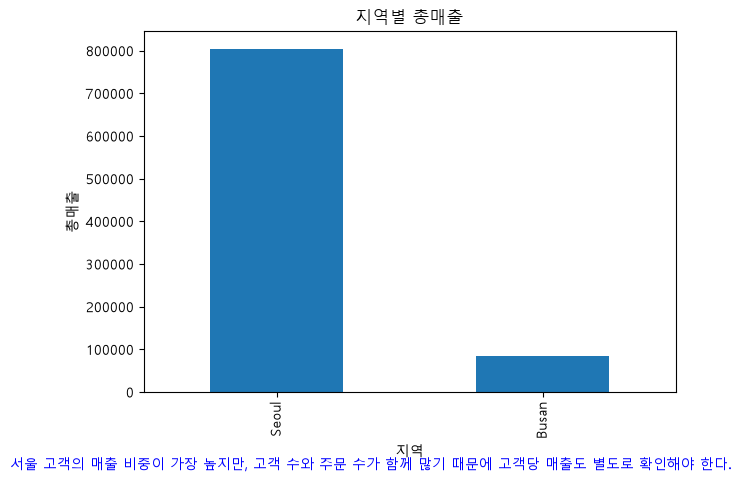

In [8]:
# 6. 그래프와 결과 저장
import matplotlib.pyplot as plt

region_summary.plot(
    x = "region",
    y = "total_sales",
    kind = "bar",
    legend = False
)

plt.rcParams["font.family"] = "Malgun Gothic" #글씨체 지정
plt.rcParams["axes.unicode_minus"] = False

plt.title("지역별 총매출")
plt.xlabel("지역")
plt.ylabel("총매출")
plt.figtext(0.5, 0.01, "서울 고객의 매출 비중이 가장 높지만, 고객 수와 주문 수가 함께 많기 때문에 고객당 매출도 별도로 확인해야 한다.",
            ha="center", fontsize=10, color="blue")
plt.tight_layout()
plt.savefig("../outputs/region_sales.png", dpi=150, bbox_inches="tight")
plt.show()

## csv 저장
customer_summary.to_csv("../outputs/customer_summary.csv", index = False, encoding = "utf-8-sig")